# Chances de sucesso de uma Reclamação no STF antes de ajuizá-la

**Atividade 1 — Projeto Parcial**
**Disciplina:** Ciência de Dados e Inteligência Artificial na Administração Pública
**Mestrando:** Marcos Meira
**Data:** setembro/2026

Este notebook apresenta o relatório preliminar da atividade, contendo: (1) a descrição do
problema; (2) a descrição da base de dados; (3) o dicionário de dados (referência ao arquivo
em Excel entregue em separado); (4) as análises descritivas iniciais; e (5) uma discussão
preliminar sobre relações entre variáveis e qualidade dos dados.


## 1. Descrição do problema

**Contexto.** A *reclamação constitucional* (classe processual "Rcl") é o instrumento
processual usado para provocar o Supremo Tribunal Federal (STF) a garantir a autoridade de
suas decisões ou a preservar sua competência, quando um órgão do Poder Judiciário (ou, em
certos casos, da Administração) profere ato que supostamente contraria uma decisão, súmula ou
tese do STF. Antes de ajuizar uma reclamação, a parte (ou seu advogado) precisa decidir se vale
a pena arcar com o custo, o tempo e o risco processual de propor a ação — decisão que hoje é
tomada de forma essencially intuitiva, com base na experiência do profissional.

**Pergunta de pesquisa.** É possível, a partir de características observáveis *no momento do
ajuizamento* (o tipo/assunto da reclamação, o segmento e a instância de origem do ato
reclamado, o tipo de decisão paradigma invocada, o regime processual vigente etc.), estimar a
probabilidade de uma reclamação vir a ser julgada **procedente** pelo STF?

**Tarefa de aprendizado supervisionado.** Trata-se de um problema de **classificação binária**:
dado um conjunto de características de uma reclamação disponíveis antes do julgamento, prever
a classe do desfecho.

**Variável-alvo (target).** A coluna `decisao`, que assume dois valores mutuamente exclusivos:
- `procedente` — o pedido da reclamação foi acolhido pelo STF;
- `improcedente` — o pedido foi rejeitado.

**Observação sobre o escopo desta entrega.** Este Projeto Parcial cobre a descrição do
problema, da base e a análise exploratória inicial. A etapa de modelagem preditiva
(engenharia de atributos, divisão treino/teste, ajuste e avaliação de modelos de classificação)
é deixada para a etapa seguinte da disciplina, apoiada nos achados desta análise exploratória.


## 2. Descrição da base de dados

**Fonte e contextualização.** Os dados utilizados nesta atividade são **dados públicos de
pesquisa acadêmica**, construídos por Lívia Pitelli Zamarian Houaiss para sua tese de doutorado
*"Reclamação constitucional e recalcitrância judicial na medida das decisões do Supremo
Tribunal Federal"* (Universidade Federal Fluminense — UFF, 2019), e disponibilizados
publicamente pelo pesquisador José de Jesus Filho no repositório
[`jjesusfilho/repotese`](https://github.com/jjesusfilho/repotese) no GitHub, junto com o código
de coleta, limpeza e análise (pacote R `stf`).

A base foi construída a partir do acervo processual público do STF: todas as decisões de
mérito (monocráticas, colegiadas e da Presidência) proferidas em reclamações constitucionais
(classe `Rcl`) entre **2011 e 2018**, com exceção de casos em segredo de justiça ou sem trânsito
em julgado no momento da coleta original. Cada linha da base corresponde a **uma decisão**
(não a um processo — um mesmo processo pode ter mais de uma decisão registrada, por exemplo
uma decisão monocrática seguida do julgamento de um agravo pelo colegiado).

**Por que reutilizar uma base de pesquisa já existente, em vez de coletar diretamente do STF?**
O ambiente de execução usado nesta atividade não tem acesso à internet dos portais
`transparencia.stf.jus.br`, `dadosabertos.stf.jus.br` e à API pública do DataJud/CNJ (bloqueio
de rede do ambiente de trabalho). Diante do prazo da entrega, optou-se por reutilizar, com
citação explícita da fonte, uma base real e já publicada, construída com metodologia
documentada (ver `procedimento.Rmd` no repositório de origem) e adequada ao problema proposto.
Para as etapas seguintes da pesquisa, permanece como possibilidade avaliar a coleta direta via
DataJud/CNJ para estender a base a anos mais recentes — ver seção de discussão, ao final.

**Objetivo da utilização.** Explorar a estrutura da base, entender a distribuição da variável-
alvo e de seus principais preditores candidatos, e identificar problemas de qualidade de dados
a serem tratados antes da futura etapa de modelagem preditiva.

**Contextualização do problema de pesquisa.** No campo de "jurimetria" (aplicação de métodos
estatísticos e de aprendizado de máquina ao estudo do comportamento judicial), a construção de
modelos preditivos de desfecho processual tem crescido como ferramenta de apoio à decisão de
litigar, de gestão de risco jurídico e de transparência sobre o funcionamento dos tribunais
(ver referencial teórico no relatório parcial em Word). O caso da reclamação constitucional é
particularmente interessante porque é um instrumento de uso crescente no STF e cuja taxa de
sucesso varia fortemente conforme o tipo de controvérsia, como será explorado adiante.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Base de dados bruta (entregue em separado como base_marcos_meira.csv)
df = pd.read_csv("base_marcos_meira.csv", parse_dates=["data_andamento", "data_autuacao"])
print(f"Dimensões da base: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Dimensões da base: 6370 linhas x 18 colunas


,incidente,data_andamento,decisao,agravo,orgao_julgador,novo_cpc,adc,adi,adpf,re,sumula,assunto,segmento,instancia,area,paradigma,efeito_vinculante,data_autuacao
0,4186352,2013-06-05,procedente,sim,Colegiada,CPC/1973,não,sim,não,não,não,TRABALHO,estadual,segunda,DIREITO DO TRABALHO,controle_concentrado,vinculante,2011-12-22
1,4693441,2015-03-04,procedente,não,Dias Toffoli,CPC/1973,não,não,não,não,não,TRABALHO E PREVIDENCIÁRIO,trabalho,segunda,DIREITO DO TRABALHO,inter_partes,nao_vinculante,2014-12-23
2,4695068,2015-03-04,procedente,não,Dias Toffoli,CPC/1973,não,não,não,não,não,TRABALHO E PREVIDENCIÁRIO,trabalho,superior,DIREITO DO TRABALHO,inter_partes,nao_vinculante,2015-01-07
3,4695444,2015-03-04,procedente,não,Dias Toffoli,CPC/1973,não,não,não,não,não,TRABALHO E PREVIDENCIÁRIO,trabalho,superior,DIREITO DO TRABALHO,inter_partes,nao_vinculante,2015-01-08
4,4695444,2015-03-04,procedente,não,Dias Toffoli,CPC/1973,não,não,não,não,não,TRABALHO E PREVIDENCIÁRIO,trabalho,segunda,DIREITO DO TRABALHO,inter_partes,nao_vinculante,2015-01-08


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6370 entries, 0 to 6369
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   incidente          6370 non-null   int64         
 1   data_andamento     6370 non-null   datetime64[us]
 2   decisao            6370 non-null   str           
 3   agravo             6370 non-null   str           
 4   orgao_julgador     6370 non-null   str           
 5   novo_cpc           6370 non-null   str           
 6   adc                6370 non-null   str           
 7   adi                6370 non-null   str           
 8   adpf               6370 non-null   str           
 9   re                 6370 non-null   str           
 10  sumula             6370 non-null   str           
 11  assunto            6252 non-null   str           
 12  segmento           6370 non-null   str           
 13  instancia          6370 non-null   str           
 14  area               

## 3. Dicionário de dados

O dicionário completo (nome da variável, nome descritivo, tipo de dado, unidade de medida,
domínio/categoria, significado e observações de qualidade) foi entregue em separado, no
arquivo **`dicionario_marcos_meira.xlsx`**, conforme exigido pela atividade. Abaixo, uma
conferência rápida de que os tipos de dado da base carregada são compatíveis com o que consta
no dicionário.


In [3]:
resumo_tipos = pd.DataFrame({
    "dtype_pandas": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "n_ausentes": df.isna().sum(),
    "%_ausentes": (df.isna().mean() * 100).round(2),
})
resumo_tipos


,dtype_pandas,n_unicos,n_ausentes,%_ausentes
incidente,int64,5479,0,0.00
data_andamento,datetime64[us],1109,0,0.00
decisao,str,2,0,0.00
agravo,str,2,0,0.00
orgao_julgador,str,13,0,0.00
novo_cpc,str,2,0,0.00
adc,str,2,0,0.00
adi,str,2,0,0.00
adpf,str,2,0,0.00
re,str,2,0,0.00


## 4. Análises descritivas iniciais

### 4.1 Variável-alvo: `decisao`


              contagem  percentual (%)
decisao                               
improcedente      3685           57.85
procedente        2685           42.15


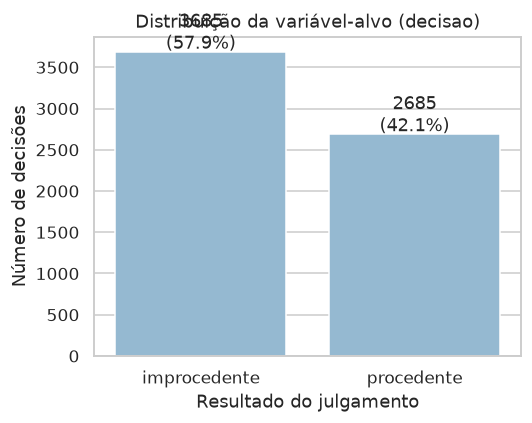

In [4]:
contagem_decisao = df["decisao"].value_counts()
proporcao_decisao = df["decisao"].value_counts(normalize=True).round(4) * 100

tabela_decisao = pd.DataFrame({
    "contagem": contagem_decisao,
    "percentual (%)": proporcao_decisao.round(2),
})
print(tabela_decisao)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=tabela_decisao.index, y=tabela_decisao["contagem"], ax=ax)
ax.set_title("Distribuição da variável-alvo (decisao)")
ax.set_xlabel("Resultado do julgamento")
ax.set_ylabel("Número de decisões")
for i, v in enumerate(tabela_decisao["contagem"]):
    ax.text(i, v + 40, f"{v}\n({tabela_decisao['percentual (%)'].iloc[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.show()


A base apresenta um desbalanceamento moderado entre as classes (aproximadamente 58% de decisões
`improcedente` e 42% `procedente`) — relevante para a etapa de modelagem futura (escolha de
métrica de avaliação e, possivelmente, técnicas de balanceamento).

### 4.2 Medidas de posição e dispersão — variáveis numéricas/derivadas

A base bruta não possui variáveis quantitativas contínuas além de identificadores e datas.
Para viabilizar uma análise de posição e dispersão, foi derivada a variável **tempo de
tramitação** (em dias), calculada como a diferença entre `data_andamento` (data da decisão) e
`data_autuacao` (data de entrada do processo no STF). Essa variável é uma candidata natural a
preditor na etapa de modelagem, embora aqui seu uso seja meramente descritivo.


In [5]:
df["tempo_tramitacao_dias"] = (df["data_andamento"] - df["data_autuacao"]).dt.days

# Linhas com tempo negativo indicam inconsistência de datas (ver seção 5 — qualidade dos dados)
print("Linhas com tempo de tramitação negativo:", (df["tempo_tramitacao_dias"] < 0).sum())

desc = df["tempo_tramitacao_dias"].describe(percentiles=[.05, .25, .5, .75, .95]).round(1)
assimetria = df["tempo_tramitacao_dias"].skew()
curtose = df["tempo_tramitacao_dias"].kurt()

print(desc)
print(f"\nAssimetria (skewness): {assimetria:.2f}")
print(f"Curtose (excesso): {curtose:.2f}")


Linhas com tempo de tramitação negativo: 0
count    6370.0
mean      439.8
std       627.0
min         2.0
5%          8.0
25%        50.0
50%       195.0
75%       549.0
95%      1708.1
max      5271.0
Name: tempo_tramitacao_dias, dtype: float64

Assimetria (skewness): 2.69
Curtose (excesso): 9.23


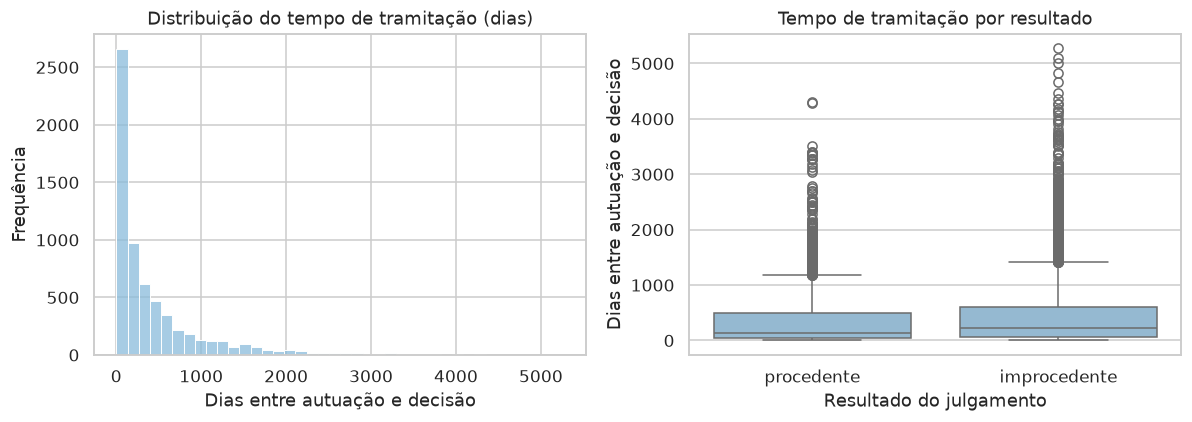

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df["tempo_tramitacao_dias"].clip(lower=0), bins=40, ax=axes[0])
axes[0].set_title("Distribuição do tempo de tramitação (dias)")
axes[0].set_xlabel("Dias entre autuação e decisão")
axes[0].set_ylabel("Frequência")

sns.boxplot(data=df, x="decisao", y=df["tempo_tramitacao_dias"].clip(lower=0), ax=axes[1])
axes[1].set_title("Tempo de tramitação por resultado")
axes[1].set_xlabel("Resultado do julgamento")
axes[1].set_ylabel("Dias entre autuação e decisão")

plt.tight_layout()
plt.show()


### 4.3 Distribuição das principais variáveis categóricas candidatas a preditoras

A seguir, a frequência das categorias de `segmento` (segmento de justiça de origem),
`assunto`/`area` (tipo/assunto da reclamação) e `paradigma` (natureza da decisão paradigma
invocada) — as três dimensões mais diretamente ligadas ao conceito de "tipo de reclamação"
mencionado no problema de pesquisa.


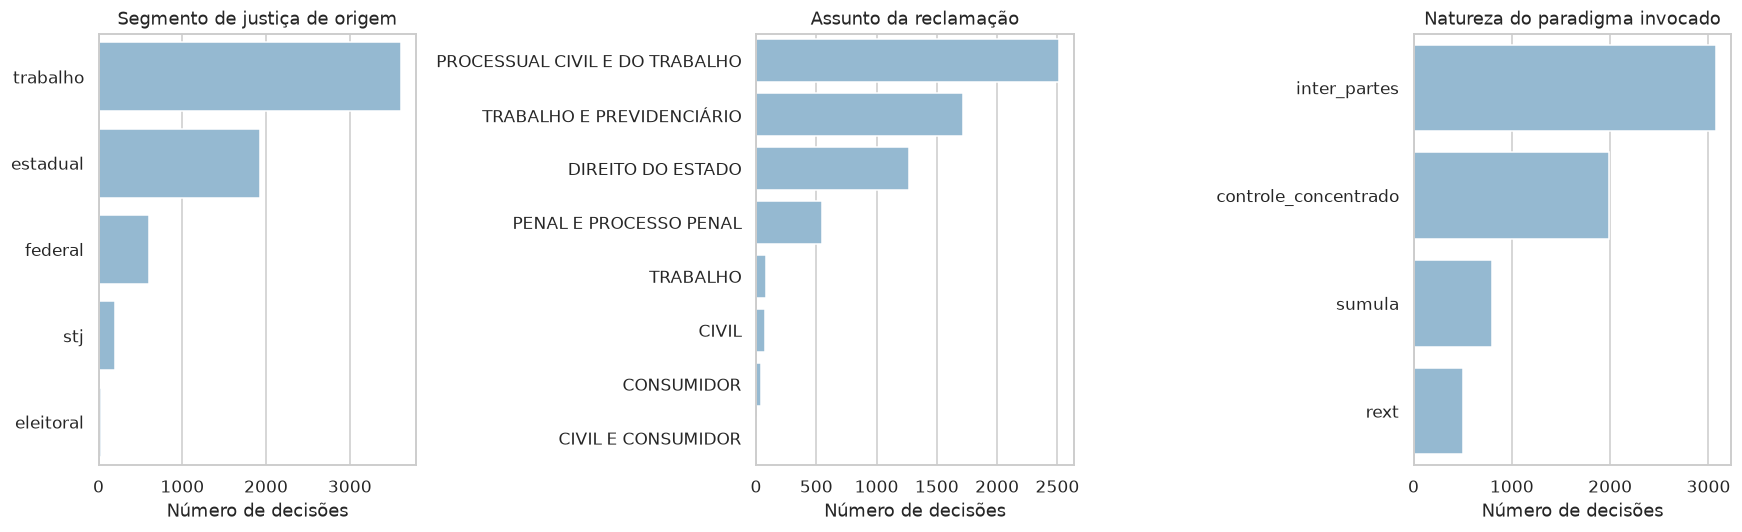

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ordem_segmento = df["segmento"].value_counts().index
sns.countplot(data=df, y="segmento", order=ordem_segmento, ax=axes[0])
axes[0].set_title("Segmento de justiça de origem")
axes[0].set_xlabel("Número de decisões")
axes[0].set_ylabel("")

ordem_assunto = df["assunto"].value_counts().index
sns.countplot(data=df, y="assunto", order=ordem_assunto, ax=axes[1])
axes[1].set_title("Assunto da reclamação")
axes[1].set_xlabel("Número de decisões")
axes[1].set_ylabel("")

ordem_paradigma = df["paradigma"].value_counts().index
sns.countplot(data=df, y="paradigma", order=ordem_paradigma, ax=axes[2])
axes[2].set_title("Natureza do paradigma invocado")
axes[2].set_xlabel("Número de decisões")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


In [8]:
for col in ["agravo", "novo_cpc", "instancia", "efeito_vinculante"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()


--- agravo ---
agravo
não    4372
sim    1998
Name: count, dtype: int64

--- novo_cpc ---
novo_cpc
CPC/1973    3788
CPC/2015    2582
Name: count, dtype: int64

--- instancia ---
instancia
segunda     3413
primeira    1717
superior    1240
Name: count, dtype: int64

--- efeito_vinculante ---
efeito_vinculante
vinculante        3291
nao_vinculante    3079
Name: count, dtype: int64



## 5. Discussão preliminar

### 5.1 Relações entre variáveis e a variável-alvo

A taxa de sucesso (percentual de decisões `procedente`) varia de forma expressiva conforme o
**assunto/segmento** da reclamação e conforme a **natureza do paradigma** invocado — exatamente
a hipótese que motiva o problema de pesquisa: "o tipo de reclamação" parece, de fato, se
relacionar com a chance de êxito.


In [9]:
def taxa_sucesso(df, coluna, min_n=20):
    tab = (
        df.groupby(coluna)["decisao"]
        .apply(lambda s: (s == "procedente").mean() * 100)
        .round(1)
    )
    n = df.groupby(coluna)["decisao"].size()
    out = pd.DataFrame({"n_decisoes": n, "taxa_sucesso_%": tab})
    out = out[out["n_decisoes"] >= min_n].sort_values("taxa_sucesso_%", ascending=False)
    return out

print("Taxa de sucesso por SEGMENTO de justiça de origem")
display(taxa_sucesso(df, "segmento"))

print("\nTaxa de sucesso por ASSUNTO")
display(taxa_sucesso(df, "assunto"))

print("\nTaxa de sucesso por natureza do PARADIGMA invocado")
display(taxa_sucesso(df, "paradigma"))

print("\nTaxa de sucesso conforme houve AGRAVO")
display(taxa_sucesso(df, "agravo"))


Taxa de sucesso por SEGMENTO de justiça de origem


,n_decisoes,taxa_sucesso_%
segmento,,
trabalho,3614,51.7
federal,600,37.2
estadual,1928,28.6
stj,193,20.7
eleitoral,35,8.6



Taxa de sucesso por ASSUNTO


,n_decisoes,taxa_sucesso_%
assunto,,
TRABALHO E PREVIDENCIÁRIO,1716,54.4
PROCESSUAL CIVIL E DO TRABALHO,2511,42.3
CONSUMIDOR,45,42.2
PENAL E PROCESSO PENAL,546,36.4
DIREITO DO ESTADO,1265,33.5
CIVIL,76,11.8
TRABALHO,85,5.9



Taxa de sucesso por natureza do PARADIGMA invocado


,n_decisoes,taxa_sucesso_%
paradigma,,
inter_partes,3079,46.8
rext,504,43.3
controle_concentrado,1993,37.0
sumula,794,36.3



Taxa de sucesso conforme houve AGRAVO


,n_decisoes,taxa_sucesso_%
agravo,,
não,4372,59.0
sim,1998,5.3


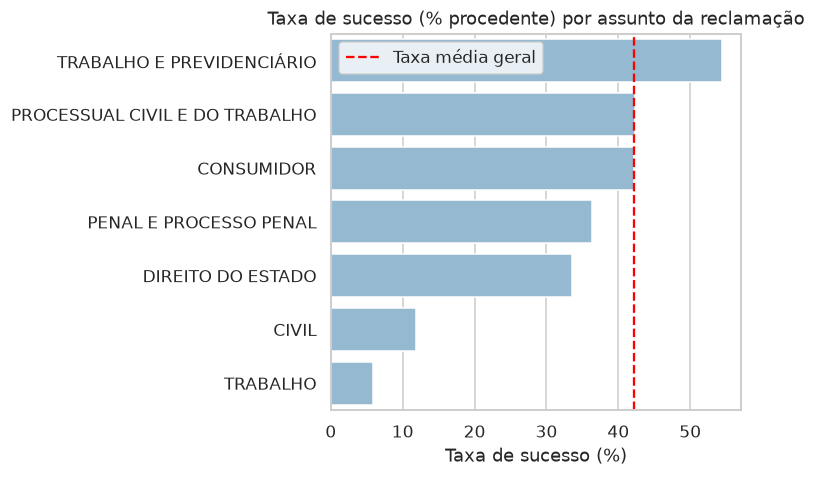

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
tab_assunto = taxa_sucesso(df, "assunto")
sns.barplot(x=tab_assunto["taxa_sucesso_%"], y=tab_assunto.index, ax=ax)
ax.axvline(x=(df["decisao"] == "procedente").mean() * 100, color="red", linestyle="--",
           label="Taxa média geral")
ax.set_title("Taxa de sucesso (% procedente) por assunto da reclamação")
ax.set_xlabel("Taxa de sucesso (%)")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
# Teste qui-quadrado de independência (indicativo/preliminar) entre `assunto` e `decisao`
tabela_contingencia = pd.crosstab(df["assunto"], df["decisao"])
chi2, p_valor, gl, esperado = stats.chi2_contingency(tabela_contingencia)
print(f"Qui-quadrado = {chi2:.2f} | graus de liberdade = {gl} | valor-p = {p_valor:.2e}")


Qui-quadrado = 224.96 | graus de liberdade = 7 | valor-p = 5.85e-45


O valor-p extremamente baixo do teste qui-quadrado indica evidência estatística preliminar de
associação entre `assunto` e `decisao` — coerente com o que os gráficos acima sugerem. Este
resultado é **apenas indicativo**: não avalia magnitude do efeito controlando por outras
variáveis (isso será tratado na etapa de modelagem multivariada, por exemplo com regressão
logística), nem pressupõe causalidade.

### 5.2 Qualidade dos dados: problemas identificados

- **Dados ausentes.** As colunas `assunto` (118 valores ausentes, ~1,9%) e `area` (85 valores
  ausentes, ~1,3%) apresentam lacunas. Como são justamente as variáveis mais próximas do
  conceito de "tipo de reclamação", será preciso decidir, na etapa de modelagem, entre
  imputação (ex.: categoria "não informado"), exclusão das linhas ou uso de uma variável
  substituta menos granular (`segmento`, que não tem ausências).

- **Padronização de categorias.** Há sobreposição e inconsistência de granularidade entre
  `assunto` e `area` (ex.: `assunto = "TRABALHO"` versus `assunto = "TRABALHO E
  PREVIDENCIÁRIO"`, ambos mapeados de forma distinta em `area`). Antes da modelagem, será
  necessário padronizar essas categorias (unificação de rótulos e/ou agrupamento de categorias
  raras) para evitar níveis com poucas observações.

- **Unidade de análise duplicada em `incidente`.** O identificador de processo (`incidente`)
  se repete em parte das linhas porque um mesmo processo pode gerar mais de uma decisão (ex.:
  decisão monocrática seguida de agravo). Isso significa que as observações **não são
  totalmente independentes entre si** — uma premissa importante de vários métodos estatísticos
  — e deverá ser considerado no desenho da futura divisão treino/teste (evitar que decisões do
  mesmo processo fiquem partidas entre treino e teste, o que configuraria vazamento de dados).

- **Inconsistência de datas.** Foram identificadas linhas com `tempo_tramitacao_dias` negativo
  (ver seção 4.2), o que sugere erro de registro entre `data_autuacao` e `data_andamento` em
  parte da base, exigindo tratamento antes de qualquer uso dessas datas como preditores.

- **Colinearidade entre variáveis de paradigma.** As colunas binárias `adc`, `adi`, `adpf`,
  `re` e `sumula` são, em grande medida, uma decomposição da própria variável `paradigma` —
  usá-las simultaneamente em um modelo pode gerar redundância/colinearidade, algo a resolver na
  fase de engenharia de atributos.

- **Desbalanceamento de categorias raras.** Categorias como `segmento = eleitoral` (n=35) ou
  `adc = sim` (n=46) têm poucas observações, o que pode tornar estimativas menos confiáveis
  para esses subgrupos e sugere agrupamento em categorias mais amplas.

### 5.3 Limitações e próximos passos

A base cobre decisões de 2011 a 2018; ela não captura eventuais mudanças de composição do STF,
de entendimento jurisprudencial ou de volume de reclamações em anos mais recentes. Como
próximo passo, pretende-se avaliar a viabilidade de estender a coleta via API pública do
DataJud/CNJ para anos posteriores a 2018, além de tratar os problemas de qualidade listados
acima antes da etapa de modelagem preditiva (regressão logística e modelos de aprendizado de
máquina, como floresta aleatória e boosting).


## Referências

- HOUAISS (PITELLI), Lívia Pitelli Zamarian. *Reclamação constitucional e recalcitrância
  judicial na medida das decisões do Supremo Tribunal Federal*. Tese de Doutorado —
  Universidade Federal Fluminense (UFF), 2019.
- JESUS FILHO, José de. *repotese*: código e base de dados da tese de Lívia Houaiss. GitHub,
  2019. Disponível em: <https://github.com/jjesusfilho/repotese>.

Referências adicionais sobre o referencial teórico (jurimetria, análise categórica e
aprendizado estatístico) constam do **relatório parcial em Word** entregue junto a esta
atividade.
